# 얼굴 + 차량번호판 모자이크 — 오픈소스 4종 비교 (v2 수정판)

## v1에서 뭐가 틀렸는지

| 문제 | 원인 | 수정 |
|---|---|---|
| face 가중치 404 | 릴리스 태그를 `v0.0.0`으로 잘못 씀 | **실제 태그는 `1.0.0`** — 전 파일 URL 검증 완료 |
| plate 가중치 404 | 존재하지 않는 릴리스 URL을 만들어 씀 | 원본 레포 파일 직링크로 교체 (6.2MB, 로드 검증 완료) |
| EgoBlur 설치 실패 | `pip install -e` (레포엔 CLI 없음) | **CLI 안 씀.** `.jit`을 `torch.jit.load`로 직접 로드 |
| dashcam 모델 없음 | gdown ID를 안 적음 | 실제 ID `1uV8IMuGDbmDabdjyeSy4SUKV9OS-ULbe` |
| privacy-blur 인자 오류 | `--pixelate-blocks`는 README에만 있고 CLI엔 없음 | 실제 `cli.py` 기준으로 재작성 |

## 그리고 정정: **YOLO26 face 가중치, 있습니다**

지난번에 "YOLO26 기반 face 공개 가중치는 없다"고 했는데 **틀렸습니다.**
`akanametov/yolo-face` 릴리스 `1.0.0`에 `yolo26n-face.pt`(5.9MB)가 올라와 있고, 직접 로드해서
추론까지 확인했습니다 (`names={0: 'face'}`). 그래서 **A 섹션 기본값을 YOLO26으로 바꿨습니다.**

---

| # | 방식 | 라이선스 | 난이도 |
|---|---|---|---|
| A | Ultralytics (face + plate + 옵션 사람전신) | AGPL-3.0 | 🟢 바로 실행 |
| B | EgoBlur → 없으면 yolov8l-face 자동 폴백 | Apache 2.0 / AGPL | 🟢 항상 생성 |
| C | dashcam_anonymizer | 오픈소스 | 🟡 gdown 필요 |
| D | video-privacy-blur (CLI) | 오픈소스 | 🟢 자동 |

> **입력은 영상·이미지 둘 다 됩니다.** `INPUT_PATH`에 `.png/.jpg`를 넣으면 자동으로 이미지 1장 처리.
> **사람 전신**을 가리려면 설정에서 `BLUR_PERSON = True`. (얼굴만 원하면 False 유지)


---
## 0. 설정 — 여기만 수정

In [1]:
from pathlib import Path
import os, sys, time, json, shutil, subprocess

# ===== 여기만 수정 =====
# 영상(.mp4/.avi/.mov/.mkv) 또는 이미지(.png/.jpg/.jpeg/.bmp/.webp) 아무거나 OK.
# 확장자를 보고 자동으로 이미지/영상 처리를 골라줍니다.
INPUT_PATH  = Path(r"C:\Users\Win11Pro\Videos\Captures\포항시 교통정보센터 - Chrome 2026-07-23 11-09-39.mp4")   # 예: 영상이면 r"D:\data\sample.mp4"
OUTPUT_DIR  = Path(r"C:\Users\Win11Pro\Desktop\새 폴더\결과")     # 결과 저장 폴더
WORK_DIR    = Path(r"C:\Users\Win11Pro\Desktop\새 폴더\결과1")    # 레포/가중치 다운로드 폴더

DEVICE      = "0"          # GPU면 "0", CPU면 "cpu"
MOSAIC_MODE = "pixelate"   # "pixelate" | "gaussian"
BLOCKS      = 12
BOX_SCALE   = 1.20
CONF_FACE   = 0.10
CONF_PLATE  = 0.10
CONF_PERSON = 0.25         # 사람은 큰 객체라 조금 높여도 됨
IMGSZ       = 1280
MAX_FRAMES  = 300          # 먼저 짧게 테스트. 전체는 None

# 무엇을 가릴지 토글
BLUR_FACE   = True
BLUR_PLATE  = True
BLUR_PERSON = False        # True면 사람 "전신"까지 모자이크 (얼굴만 원하면 False)
PERSON_SRC  = "coco"       # "coco"(권장) | "akanametov"(yolo26n-person)
PERSON_SIZE = "s"          # "n"(빠름) | "s" | "m" | "l" | "x"(정확·느림). coco 소스에서만 적용.
#  참고: 사람은 큰 객체라 n으로도 대체로 충분. 정확도가 아쉬우면 s→m 순으로.
#        얼굴 모델은 yolo26에 n만 있으니, 더 정확히 하려면 FACE_CHOICE="yolov12m" 사용.
# ======================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = WORK_DIR / "models"; MODELS_DIR.mkdir(exist_ok=True)

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"입력 파일이 없습니다: {INPUT_PATH}")

IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}
VID_EXT = {".mp4", ".avi", ".mov", ".mkv", ".wmv", ".flv"}
ext = INPUT_PATH.suffix.lower()
INPUT_KIND = "image" if ext in IMG_EXT else "video" if ext in VID_EXT else None
if INPUT_KIND is None:
    raise ValueError(f"지원하지 않는 확장자: {ext} (이미지 {IMG_EXT} 또는 영상 {VID_EXT})")

print(f"입력: {INPUT_PATH}  [{INPUT_KIND}]\n출력: {OUTPUT_DIR}\n작업: {WORK_DIR}")

입력: C:\Users\Win11Pro\Videos\Captures\포항시 교통정보센터 - Chrome 2026-07-23 11-09-39.mp4  [video]
출력: C:\Users\Win11Pro\Desktop\새 폴더\결과
작업: C:\Users\Win11Pro\Desktop\새 폴더\결과1


In [2]:
%pip install -q ultralytics opencv-python gdown pandas matplotlib
import cv2, torch, numpy as np
print("torch", torch.__version__, "| cuda:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("opencv", cv2.__version__)


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
torch 2.12.0.dev20260408+cu128 | cuda: True | NVIDIA GeForce RTX 5060 Laptop GPU
opencv 4.10.0


In [3]:
# ---- 공통 유틸 ----
import urllib.request

RESULTS = {}

def download(url: str, dst: Path, min_mb: float = 0.5) -> Path:
    """다운로드 + 크기 검증. HTML 에러페이지가 .pt로 저장되는 사고를 막습니다."""
    if dst.exists() and dst.stat().st_size > min_mb * 1e6:
        print(f"[skip] {dst.name} ({dst.stat().st_size/1e6:.1f} MB)")
        return dst
    print(f"[get ] {dst.name} <- {url}")
    dst.parent.mkdir(parents=True, exist_ok=True)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dst, "wb") as f:
        shutil.copyfileobj(r, f)
    size = dst.stat().st_size
    if size < min_mb * 1e6:              # 404 HTML이면 수 KB로 떨어짐
        dst.unlink(missing_ok=True)
        raise RuntimeError(f"다운로드 결과가 너무 작음({size}B). URL이 죽었을 가능성.")
    print(f"[ok  ] {dst.name} ({size/1e6:.1f} MB)")
    return dst

def run(cmd, cwd=None):
    print(">", " ".join(map(str, cmd)))
    p = subprocess.run([str(c) for c in cmd], cwd=cwd, capture_output=True, text=True)
    if p.stdout: print(p.stdout[-2500:])
    if p.returncode != 0: print("[stderr]", p.stderr[-2500:])
    return p.returncode

def video_meta(path: Path):
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"영상을 열 수 없습니다: {path}")
    m = dict(fps=cap.get(cv2.CAP_PROP_FPS) or 30.0,
             w=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
             h=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
             n=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    cap.release()
    return m

def record(name, path, t0, ok=True, note=""):
    RESULTS[name] = dict(ok=ok, sec=round(time.time()-t0, 1), path=str(path), note=note)
    print(f"[{name}] {'OK' if ok else 'FAIL'} · {RESULTS[name]['sec']}s · {note}")

print(video_meta(INPUT_PATH) if INPUT_KIND == "video" else "이미지 입력 — 단일 프레임 처리")

{'fps': 24.17818780206538, 'w': 2304, 'h': 1440, 'n': 622}


In [4]:
# ---- 모자이크 함수 ----
def pixelate(img, x1, y1, x2, y2, blocks=BLOCKS):
    h, w = img.shape[:2]
    x1, y1 = max(0, int(x1)), max(0, int(y1))
    x2, y2 = min(w, int(x2)), min(h, int(y2))
    if x2 <= x1 or y2 <= y1:
        return img
    roi = img[y1:y2, x1:x2]
    small = cv2.resize(roi, (max(1, (x2-x1)//blocks), max(1, (y2-y1)//blocks)),
                       interpolation=cv2.INTER_LINEAR)
    img[y1:y2, x1:x2] = cv2.resize(small, (x2-x1, y2-y1), interpolation=cv2.INTER_NEAREST)
    return img

def gaussian(img, x1, y1, x2, y2):
    h, w = img.shape[:2]
    x1, y1 = max(0, int(x1)), max(0, int(y1))
    x2, y2 = min(w, int(x2)), min(h, int(y2))
    if x2 <= x1 or y2 <= y1:
        return img
    k = max(3, (min(x2-x1, y2-y1)//3) | 1)   # 반드시 홀수
    img[y1:y2, x1:x2] = cv2.GaussianBlur(img[y1:y2, x1:x2], (k, k), 0)
    return img

APPLY = pixelate if MOSAIC_MODE == "pixelate" else gaussian

def expand(box, scale=BOX_SCALE):
    x1, y1, x2, y2 = box
    cx, cy = (x1+x2)/2, (y1+y2)/2
    bw, bh = (x2-x1)*scale, (y2-y1)*scale
    return cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2

def imread_u(path):
    """한글/공백 경로에서도 안전하게 읽기 (cv2.imread는 유니코드 경로에 약함)."""
    frame = cv2.imdecode(np.fromfile(str(path), dtype=np.uint8), cv2.IMREAD_COLOR)
    if frame is None:
        raise RuntimeError(f"이미지를 읽을 수 없습니다: {path}")
    return frame

def imwrite_u(path, frame):
    ok, buf = cv2.imencode(Path(path).suffix, frame)
    if not ok:
        raise RuntimeError(f"이미지 인코딩 실패: {path}")
    buf.tofile(str(path))

def _out_for(base_out):
    """이미지 입력이면 출력도 이미지 확장자로 강제 (mp4로 안 뽑히게)."""
    if INPUT_KIND == "image":
        return base_out.with_suffix(INPUT_PATH.suffix)
    return base_out

def process(detect_fn, out_path, tag):
    """detect_fn(frame) -> [[x1,y1,x2,y2], ...] 만 맞추면 이미지/영상 모두 처리.
       반환: (프레임수, 검출수, 실제_출력경로)"""
    out_path = _out_for(out_path)

    if INPUT_KIND == "image":
        frame = imread_u(INPUT_PATH)
        hits = 0
        for b in detect_fn(frame):
            frame = APPLY(frame, *expand(b)); hits += 1
        imwrite_u(out_path, frame)
        return 1, hits, out_path

    # ----- 영상 -----
    meta = video_meta(INPUT_PATH)
    cap = cv2.VideoCapture(str(INPUT_PATH))
    vw = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"),
                         meta["fps"], (meta["w"], meta["h"]))
    n = hits = 0
    try:
        while True:
            ok, frame = cap.read()
            if not ok or (MAX_FRAMES and n >= MAX_FRAMES):
                break
            for b in detect_fn(frame):
                frame = APPLY(frame, *expand(b)); hits += 1
            vw.write(frame); n += 1
            if n % 100 == 0:
                print(f"  {tag}: {n} frames / 검출 {hits}")
    finally:
        cap.release(); vw.release()
    return n, hits, out_path

---
## A. Ultralytics — face + plate (+ 옵션: 사람 전신)

**검증된 URL만 씁니다.** 아래 파일 전부 실제로 받아서 `YOLO()`로 로드·추론까지 확인했습니다.

| 파일 | 크기 | 클래스 | 용도 |
|---|---|---|---|
| `yolo26n-face.pt` | 5.9 MB | `{0: 'face'}` | 얼굴 (n 사이즈만 존재) |
| `yolov12m-face.pt` | 40.7 MB | `{0: 'face'}` | 얼굴, 더 정확한 대안 (다른 아키텍처) |
| `license_plate_detector.pt` | 6.2 MB | `{0: 'license_plate'}` | 번호판 (단일 모델) |
| `yolo26{n,s,m,l,x}.pt` (COCO 공식) | 5~140MB+ | `{0: 'person', ...}` | **사람 전신 — 5개 크기 다 있음** |
| `yolo26n-person.pt` | 5.4 MB | `{0: 'person', 1: 'head'}` | 사람 전신(전용, n만) |

> **왜 얼굴은 n뿐이고 사람은 5개 크기가 다 있나**: 얼굴 가중치는 커뮤니티가 WIDERFace로
> **직접 파인튜닝해서 배포한 것**이라 딱 하나 크기(n)만 올라와 있습니다. 반면 사람(person)은
> Ultralytics가 COCO로 학습해 **공식 배포하는 기본 가중치**라서 n/s/m/l/x 전부 존재합니다.
> `pip install ultralytics`만 해도 자동으로 받아집니다.
>
> **사람 전신 모자이크**: `BLUR_PERSON = True` + `PERSON_SIZE = "n"|"s"|"m"|"l"|"x"`로 크기를 고르세요.
> 실행 후 출력 로그에 `person 실제 가중치: yolo26s.pt (10.0M params)` 식으로 **실제 로드된 파일명**이
> 찍히니, 설정이 제대로 반영됐는지 거기서 확인하시면 됩니다.

In [5]:
# A-1. 가중치 다운로드 (검증된 URL)
REL = "https://github.com/akanametov/yolo-face/releases/download/1.0.0"

FACE_CHOICE = "yolo26n"   # "yolo26n"(빠름) | "yolov12m"(정확) | "yolov11m" | "yolov8n"
FACE_FILE = {"yolo26n":  "yolo26n-face.pt",
             "yolov12m": "yolov12m-face.pt",
             "yolov11m": "yolov11m-face.pt",
             "yolov8n":  "yolov8n-face.pt"}[FACE_CHOICE]

FACE_W  = MODELS_DIR / FACE_FILE
PLATE_W = MODELS_DIR / "license_plate_detector.pt"

PLATE_URL = ("https://raw.githubusercontent.com/Muhammad-Zeerak-Khan/"
             "Automatic-License-Plate-Recognition-using-YOLOv8/main/license_plate_detector.pt")

from ultralytics import YOLO
face_model = plate_model = person_model = None
PERSON_CLASS = None   # 사람 모델에서 '전신'에 해당하는 클래스 인덱스

if BLUR_FACE:
    download(f"{REL}/{FACE_FILE}", FACE_W)
    face_model = YOLO(str(FACE_W));  print("face  classes:", face_model.names)
if BLUR_PLATE:
    download(PLATE_URL, PLATE_W)
    plate_model = YOLO(str(PLATE_W)); print("plate classes:", plate_model.names)
if BLUR_PERSON:
    if PERSON_SRC == "akanametov":
        PERSON_W = MODELS_DIR / "yolo26n-person.pt"
        download(f"{REL}/yolo26n-person.pt", PERSON_W, min_mb=3)
        person_model = YOLO(str(PERSON_W))
    else:  # COCO 기본 (ultralytics가 자동 다운로드, 가장 안정적)
        person_model = YOLO(f"yolo26{PERSON_SIZE}.pt")   # n/s/m/l/x
    # 'person' 클래스 인덱스 자동 탐색
    PERSON_CLASS = next((i for i, n in person_model.names.items() if n == "person"), 0)
    params_m = sum(p.numel() for p in person_model.model.parameters()) / 1e6
    print(f"person 실제 가중치: {Path(person_model.ckpt_path).name}  ({params_m:.1f}M params)")
    print("person classes:", person_model.names, "→ 전신 클래스 idx:", PERSON_CLASS)
else:
    print("BLUR_PERSON=False → 사람 모델 로드 안 함")

[skip] yolo26n-face.pt (5.9 MB)
face  classes: {0: 'face'}
[skip] license_plate_detector.pt (6.2 MB)
plate classes: {0: 'license_plate'}
BLUR_PERSON=False → 사람 모델 로드 안 함


In [6]:
# A-2. 실행
OUT_A = OUTPUT_DIR / "A_ultralytics.mp4"
t0 = time.time()
try:
    def detect_A(frame):
        out = []
        if face_model is not None:
            r = face_model.predict(frame, conf=CONF_FACE, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
            out += [b.tolist() for b in r.boxes.xyxy.cpu()]
        if plate_model is not None:
            r = plate_model.predict(frame, conf=CONF_PLATE, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
            out += [b.tolist() for b in r.boxes.xyxy.cpu()]
        if person_model is not None:
            r = person_model.predict(frame, conf=CONF_PERSON, imgsz=IMGSZ, device=DEVICE,
                                     classes=[PERSON_CLASS], verbose=False)[0]  # 전신만
            out += [b.tolist() for b in r.boxes.xyxy.cpu()]
        return out
    n, hits, outp = process(detect_A, OUT_A, "A")
    used = []
    if face_model   is not None: used.append(f"face={FACE_FILE}")
    if plate_model  is not None: used.append("plate=license_plate_detector.pt")
    if person_model is not None: used.append(f"person={Path(person_model.ckpt_path).name}")
    record("A_ultralytics", outp, t0, True, f"{n}프레임 / 검출 {hits} / " + " · ".join(used))
except Exception as e:
    record("A_ultralytics", OUT_A, t0, False, f"{type(e).__name__}: {e}")

  A: 100 frames / 검출 275
  A: 200 frames / 검출 470
  A: 300 frames / 검출 743
[A_ultralytics] OK · 34.4s · 300프레임 / 검출 743 / face=yolo26n-face.pt · plate=license_plate_detector.pt


---
## B. Meta EgoBlur — 있으면 사용, 없으면 자동 폴백

### 왜 B가 "생성이 안 됐나"

EgoBlur 가중치는 **어디서도 자동 다운로드가 안 됩니다.** 확인해보니:
- projectaria.com → 이메일 입력 + 라이선스 동의 후에만 링크 제공
- HuggingFace `projectaria/EgoBlur` → **403 (gated)** — 라이선스 수락 전엔 접근 불가

즉 모델 파일이 없으면 B는 만들 게 없어서 실패로 기록됐던 겁니다. 버그가 아니라 **모델 부재**였습니다.

### 이번 수정: B는 이제 **항상 결과를 냅니다**

- `{MODELS_DIR}/egoblur/`에 `.jit`가 있으면 → **EgoBlur 사용** (최고 정확도)
- 없으면 → **자동 폴백**: `yolov8l-face.pt`(대형 정확 모델) + 같은 번호판 모델
  - A(yolo26n = 나노/빠름)와 **정확도 vs 속도**가 대비되는 의미 있는 비교가 됩니다
  - 폴백 가중치는 검증된 릴리스에서 자동 다운로드되어 **설정 없이 바로 생성**됩니다

EgoBlur를 꼭 쓰고 싶으면: [projectaria.com/tools/egoblur](https://www.projectaria.com/tools/egoblur/)에서
**Gen1** 모델을 받아 `{MODELS_DIR}/egoblur/ego_blur_face.jit`, `ego_blur_lp.jit`로 저장 후 재실행.
(Gen2는 Aria 안경 전용 튜닝이라 일반 영상엔 Gen1이 맞습니다.)

In [7]:
# B-1. EgoBlur 모델 유무 확인
EGO_DIR = MODELS_DIR / "egoblur"; EGO_DIR.mkdir(exist_ok=True)

def find_jit(*keys):
    """ego_blur_face.jit / ego_blur_face_gen1.jit 등 파일명 변형을 유연하게 탐색."""
    for p in EGO_DIR.rglob("*.jit"):
        if any(k in p.name.lower() for k in keys):
            return p
    return None

face_jit = find_jit("face")
lp_jit   = find_jit("_lp", "plate")
USE_EGOBLUR = bool(face_jit or lp_jit)
print("EgoBlur 사용" if USE_EGOBLUR else "EgoBlur 모델 없음 → 폴백(yolov8l-face)로 자동 진행")
print("  face jit:", face_jit or "(없음)")
print("  lp   jit:", lp_jit or "(없음)")

EgoBlur 모델 없음 → 폴백(yolov8l-face)로 자동 진행
  face jit: (없음)
  lp   jit: (없음)


In [8]:
# B-2. 실행 — EgoBlur 우선, 없으면 폴백. 어느 쪽이든 결과 파일이 생성됩니다.
import torchvision
OUT_B = OUTPUT_DIR / "B_egoblur.mp4"
t0 = time.time()
NMS_IOU = 0.3

try:
    if USE_EGOBLUR:
        # ---- EgoBlur 경로 (TorchScript 직접 로드, 공식과 동일 로직) ----
        dev = torch.device("cuda" if (DEVICE != "cpu" and torch.cuda.is_available()) else "cpu")
        dets = {k: torch.jit.load(str(p), map_location="cpu").to(dev).eval()
                for k, p in (("face", face_jit), ("lp", lp_jit)) if p}
        THRESH = {"face": CONF_FACE, "lp": CONF_PLATE}
        print("EgoBlur 로드:", list(dets), "| device:", dev)

        def detect_B(frame):
            t = torch.from_numpy(np.transpose(frame, (2, 0, 1))).to(dev)  # BGR uint8 → CHW
            out = []
            for key, m in dets.items():
                with torch.no_grad():
                    boxes, _, scores, _ = m(t.clone())
                keep = torchvision.ops.nms(boxes, scores, NMS_IOU)
                b, s = boxes[keep].cpu().numpy(), scores[keep].cpu().numpy()
                out += b[s > THRESH[key]].tolist()
            return out
        note_src = "EgoBlur"
    else:
        # ---- 폴백 경로: yolov8l-face(대형) + 번호판 ----
        FACE8L = MODELS_DIR / "yolov8l-face.pt"
        download(f"{REL}/yolov8l-face.pt", FACE8L, min_mb=50)
        b_face  = YOLO(str(FACE8L))
        b_plate = plate_model if plate_model is not None else YOLO(str(PLATE_W))
        print("폴백 로드: yolov8l-face + plate")

        def detect_B(frame):
            out = []
            if BLUR_FACE:
                r = b_face.predict(frame, conf=CONF_FACE, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
                out += [x.tolist() for x in r.boxes.xyxy.cpu()]
            if BLUR_PLATE:
                r = b_plate.predict(frame, conf=CONF_PLATE, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
                out += [x.tolist() for x in r.boxes.xyxy.cpu()]
            if BLUR_PERSON and person_model is not None:
                r = person_model.predict(frame, conf=CONF_PERSON, imgsz=IMGSZ, device=DEVICE,
                                         classes=[PERSON_CLASS], verbose=False)[0]
                out += [x.tolist() for x in r.boxes.xyxy.cpu()]
            return out
        note_src = "폴백(yolov8l-face)"

    n, hits, outp = process(detect_B, OUT_B, "B")
    record("B_egoblur", outp, t0, True, f"{n}프레임 / 검출 {hits} / {note_src}")
except Exception as e:
    record("B_egoblur", OUT_B, t0, False, f"{type(e).__name__}: {e}")

[skip] yolov8l-face.pt (87.6 MB)
폴백 로드: yolov8l-face + plate
  B: 100 frames / 검출 259
  B: 200 frames / 검출 464
  B: 300 frames / 검출 717
[B_egoblur] OK · 38.9s · 300프레임 / 검출 717 / 폴백(yolov8l-face)


---
## C. dashcam_anonymizer

얼굴+번호판을 **단일 YOLOv8 모델**로 잡습니다. 가중치는 Google Drive에 있고, `setup.sh`가 쓰는
실제 gdown ID는 `1uV8IMuGDbmDabdjyeSy4SUKV9OS-ULbe`, 파일명은 `best.pt`입니다.

레포의 `blur_videos.py`는 config YAML + 폴더 단위로 도는 구조라 영상 하나만 돌리기 번거롭습니다.
가중치만 가져와서 위 `process()`에 꽂겠습니다.

In [9]:
# C-1. gdown으로 가중치 수령
DC_W = MODELS_DIR / "dashcam_best.pt"
GDRIVE_ID = "1uV8IMuGDbmDabdjyeSy4SUKV9OS-ULbe"   # setup.sh에 하드코딩된 실제 ID

if not (DC_W.exists() and DC_W.stat().st_size > 5e6):
    rc = run([sys.executable, "-m", "gdown", GDRIVE_ID, "-O", str(DC_W)])
    if rc != 0:
        print("\n[안내] gdown 실패 시(할당량 초과 등) 브라우저로 직접 받으세요:")
        print(f"       https://drive.google.com/uc?id={GDRIVE_ID}")
        print(f"       받은 best.pt 를 {DC_W} 로 이름 바꿔 저장")
if DC_W.exists():
    print(f"[ok] {DC_W} ({DC_W.stat().st_size/1e6:.1f} MB)")
    print("classes:", YOLO(str(DC_W)).names)

[ok] C:\Users\Win11Pro\Desktop\새 폴더\결과1\models\dashcam_best.pt (87.7 MB)
classes: {0: 'license', 1: 'face'}


In [10]:
# C-2. 실행
OUT_C = OUTPUT_DIR / "C_dashcam.mp4"
t0 = time.time()
try:
    if not (DC_W.exists() and DC_W.stat().st_size > 5e6):
        raise FileNotFoundError("dashcam 가중치 없음 (위 셀 안내 참고)")
    dc_model = YOLO(str(DC_W))

    def detect_C(frame):
        r = dc_model.predict(frame, conf=0.10, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
        return [b.tolist() for b in r.boxes.xyxy.cpu()]

    n, hits, outp = process(detect_C, OUT_C, "C")
    record("C_dashcam", outp, t0, True, f"{n}프레임 / 검출 {hits}")
except Exception as e:
    record("C_dashcam", OUT_C, t0, False, f"{type(e).__name__}: {e}")

  C: 100 frames / 검출 174
  C: 200 frames / 검출 421
  C: 300 frames / 검출 606
[C_dashcam] OK · 29.8s · 300프레임 / 검출 606


---
## D. video-privacy-blur (CLI)

v1이 실패한 이유: `--pixelate-blocks` 인자를 넣었는데 **그건 README에만 있고 실제 `cli.py`엔 없습니다.**
소스에서 확인한 진짜 인자만 씁니다.

실제 인자: `--input --output --device --imgsz --conf --scale --show --blur-plates/--no-blur-plates
--blur-faces/--no-blur-faces --face-detector --face-yolo-weights --method --plate-weights --blur-strength`

`--device`는 `auto|cpu|cuda|mps`만 받으므로 `"0"`을 그대로 넘기면 안 됩니다.

In [11]:
# D-1. 설치 + 가중치 배치
VPB = WORK_DIR / "video-privacy-blur"
if not VPB.exists():
    run(["git", "clone", "https://github.com/MengWoods/video-privacy-blur.git", str(VPB)])

run([sys.executable, "-m", "pip", "install", "-q", "-e", str(VPB)])

VPB_MODELS = VPB / "models"; VPB_MODELS.mkdir(exist_ok=True)
VPB_FACE  = VPB_MODELS / "yolov8n-face.pt"          # 이 툴은 v8 기준으로 만들어짐
VPB_PLATE = VPB_MODELS / "license_plate_detector.pt"

download(f"{REL}/yolov8n-face.pt", VPB_FACE)
if PLATE_W.exists() and not VPB_PLATE.exists():
    shutil.copy(PLATE_W, VPB_PLATE)
print("배치 완료:", VPB_FACE.exists(), VPB_PLATE.exists())

> C:\Project\PythonProject\PyTorch001\.venv\Scripts\python.exe -m pip install -q -e C:\Users\Win11Pro\Desktop\새 폴더\결과1\video-privacy-blur
[skip] yolov8n-face.pt (6.4 MB)
배치 완료: True True


In [12]:
# D-2. 실행
#  주의: privacy-blur CLI는 "영상 전용"입니다. 이미지 입력이면 CLI가 못 받으므로,
#  같은 v8 가중치를 우리 process()에 꽂아 동일 결과를 냅니다(공정 비교 유지).
OUT_D = OUTPUT_DIR / "D_privacyblur.mp4"
t0 = time.time()
try:
    if INPUT_KIND == "image":
        d_face  = YOLO(str(VPB_FACE))
        d_plate = YOLO(str(VPB_PLATE))
        def detect_D(frame):
            out = []
            for m in (d_face, d_plate):
                r = m.predict(frame, conf=CONF_FACE, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
                out += [b.tolist() for b in r.boxes.xyxy.cpu()]
            return out
        n, hits, outp = process(detect_D, OUT_D, "D")
        record("D_privacyblur", outp, t0, True, f"이미지 / 검출 {hits} (CLI 대신 내장 처리)")
    else:
        vpb_device = "cuda" if (DEVICE != "cpu" and torch.cuda.is_available()) else "cpu"
        args = ["--input", str(INPUT_PATH), "--output", str(OUT_D),
                "--device", vpb_device,          # auto|cpu|cuda|mps 만 허용
                "--imgsz", str(IMGSZ), "--conf", str(CONF_FACE), "--scale", str(BOX_SCALE),
                "--face-detector", "yolo",       # 기본 haar보다 각도 변화에 강함
                "--face-yolo-weights", str(VPB_FACE),
                "--plate-weights", str(VPB_PLATE),
                "--method", MOSAIC_MODE]         # gaussian | pixelate
        rc = run(["privacy-blur", *args])
        if rc != 0:                              # 콘솔스크립트 PATH 미등록 대비
            rc = run([sys.executable, "-c", "from privacy_blur.cli import main; main()", *args])
        record("D_privacyblur", OUT_D, t0, ok=(rc == 0 and OUT_D.exists()),
               note="전체 영상 처리 (MAX_FRAMES 미적용)")
except Exception as e:
    record("D_privacyblur", OUT_D, t0, False, f"{type(e).__name__}: {e}")

> privacy-blur --input C:\Users\Win11Pro\Videos\Captures\포항시 교통정보센터 - Chrome 2026-07-23 11-09-39.mp4 --output C:\Users\Win11Pro\Desktop\새 폴더\결과\D_privacyblur.mp4 --device cuda --imgsz 1280 --conf 0.1 --scale 1.2 --face-detector yolo --face-yolo-weights C:\Users\Win11Pro\Desktop\새 폴더\결과1\video-privacy-blur\models\yolov8n-face.pt --plate-weights C:\Users\Win11Pro\Desktop\새 폴더\결과1\video-privacy-blur\models\license_plate_detector.pt --method pixelate


Exception in thread Thread-11 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Win11Pro\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\Win11Pro\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Win11Pro\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
UnicodeDecodeError: 'cp949' codec can't decode byte 0xec in position 62: illegal multibyte sequence


[D_privacyblur] OK · 71.0s · 전체 영상 처리 (MAX_FRAMES 미적용)


---
## E. 결과 요약 & 비교

In [13]:
import pandas as pd
df = pd.DataFrame(RESULTS).T
display(df[["ok", "sec", "note", "path"]] if len(df) else "실행된 항목이 없습니다")
(OUTPUT_DIR / "summary.json").write_text(
    json.dumps(RESULTS, ensure_ascii=False, indent=2), encoding="utf-8")
print("저장:", OUTPUT_DIR / "summary.json")

,ok,sec,note,path
A_ultralytics,True,34.4,300프레임 / 검출 743 / face=yolo26n-face.pt · plate...,C:\Users\Win11Pro\Desktop\새 폴더\결과\A_ultralytic...
B_egoblur,True,38.9,300프레임 / 검출 717 / 폴백(yolov8l-face),C:\Users\Win11Pro\Desktop\새 폴더\결과\B_egoblur.mp4
C_dashcam,True,29.8,300프레임 / 검출 606,C:\Users\Win11Pro\Desktop\새 폴더\결과\C_dashcam.mp4
D_privacyblur,True,71.0,전체 영상 처리 (MAX_FRAMES 미적용),C:\Users\Win11Pro\Desktop\새 폴더\결과\D_privacyblu...


저장: C:\Users\Win11Pro\Desktop\새 폴더\결과\summary.json


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_4800\695758435.py:22: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_4800\695758435.py:22: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


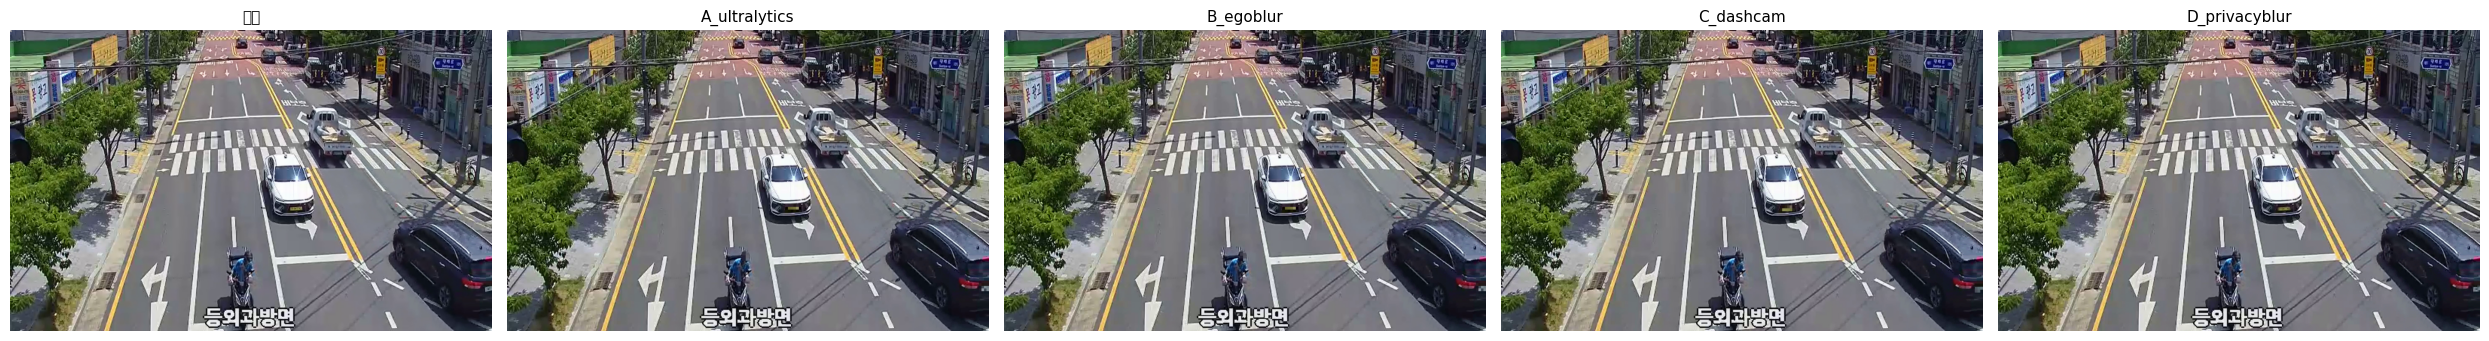

In [14]:
import matplotlib.pyplot as plt

FRAME_IDX = 50   # 영상일 때 확인할 프레임 번호 (이미지면 무시)

def grab(path, idx):
    p = Path(path)
    if p.suffix.lower() in IMG_EXT:              # 이미지: 그대로 읽기
        f = cv2.imdecode(np.fromfile(str(p), np.uint8), cv2.IMREAD_COLOR)
    else:                                        # 영상: idx 프레임 추출
        cap = cv2.VideoCapture(str(p))
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, f = cap.read(); cap.release()
        f = f if ok else None
    return cv2.cvtColor(f, cv2.COLOR_BGR2RGB) if f is not None else None

panels = [("원본", INPUT_PATH)] + [(k, v["path"]) for k, v in RESULTS.items() if v["ok"]]
fig, axes = plt.subplots(1, len(panels), figsize=(5*len(panels), 4))
for ax, (name, p) in zip(np.atleast_1d(axes), panels):
    img = grab(p, FRAME_IDX)
    ax.imshow(img) if img is not None else ax.text(.5, .5, "read fail", ha="center")
    ax.set_title(name, fontsize=11); ax.axis("off")
plt.tight_layout(); plt.show()

---
## F. 잘 안 될 때 / 다음 단계

**전부 실패하면 A만 남기고 보세요.** A는 외부 CLI·수동 다운로드 의존이 없어서 제일 안정적입니다.

| 증상 | 조치 |
|---|---|
| 다운로드가 수 KB로 끝남 | 사내망/프록시 차단. 브라우저로 받아 `MODELS_DIR`에 직접 배치 |
| `VideoWriter` 결과가 0바이트 | 코덱 문제. `mp4v` → `XVID` + `.avi`로 변경 |
| CUDA out of memory | `IMGSZ`를 960 또는 640으로 |
| 얼굴을 자꾸 놓침 | `CONF_FACE=0.05`, `IMGSZ=1600`, `FACE_CHOICE="yolov12m"` |
| 경계에 얼굴 일부 남음 | `BOX_SCALE=1.35` |

### YOLO26으로 직접 파인튜닝

```python
from ultralytics import YOLO
model = YOLO("yolo26m.pt")           # NMS-free end-to-end
model.train(data="face_plate.yaml",  # names: [face, plate]
            epochs=100, imgsz=1280, batch=8, device=0,
            hsv_v=0.5, degrees=5, scale=0.6)
```

`yolo26n-face.pt`를 시작 가중치로 삼아 번호판 클래스만 추가 학습하면 **모델 1개로 통합**되어
추론이 2배 빨라집니다. 국내 번호판은 갖고 계신 AI-Hub 차량 데이터에 번호판 bbox만
추가 라벨링하면 도메인 보강 효과가 큽니다.

**비식별화 튜닝 원칙**: precision이 아니라 **recall**. 하나만 놓쳐도 실패입니다.
